In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'g4/'

# Load all metrics
cart = pd.read_csv(f'{DATA_DIR}metrics/cart-service.csv', parse_dates=['timestamp'])
order = pd.read_csv(f'{DATA_DIR}metrics/order-service.csv', parse_dates=['timestamp'])
payment = pd.read_csv(f'{DATA_DIR}metrics/payment-service.csv', parse_dates=['timestamp'])
gateway = pd.read_csv(f'{DATA_DIR}metrics/api-gateway.csv', parse_dates=['timestamp'])
product = pd.read_csv(f'{DATA_DIR}metrics/product-service.csv', parse_dates=['timestamp'])

print("=== Dataset shapes ===")
for name, df in [('cart-service', cart), ('order-service', order),
                  ('payment-service', payment), ('api-gateway', gateway),
                  ('product-service', product)]:
    print(f"  {name}: {df.shape[0]} rows, {df.shape[1]} cols, "
          f"range: {df['timestamp'].min()} → {df['timestamp'].max()}")

print("\n=== cart-service columns ===")
print(cart.columns.tolist())
print("\n=== cart-service describe ===")
cart.describe().round(2)


=== Dataset shapes ===
  cart-service: 2820 rows, 9 cols, range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00
  order-service: 2820 rows, 5 cols, range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00
  payment-service: 2820 rows, 5 cols, range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00
  api-gateway: 2820 rows, 7 cols, range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00
  product-service: 2820 rows, 5 cols, range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00

=== cart-service columns ===
['timestamp', 'memory_usage_bytes', 'memory_limit_bytes', 'cpu_usage_percent', 'http_requests_per_sec', 'http_p99_latency_ms', 'http_5xx_rate', 'jvm_gc_pause_ms_avg', 'container_restart_count']

=== cart-service describe ===


,memory_usage_bytes,memory_limit_bytes,cpu_usage_percent,http_requests_per_sec,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count
count,2.820000e+03,2.820000e+03,2820.00,2820.00,2820.00,2820.00,2820.00,2820.00
mean,5.642055e+08,2.147484e+09,30.53,47.10,232.80,1.61,57.65,0.49
std,2.800558e+08,0.000000e+00,13.25,11.81,319.45,3.08,32.99,1.36
min,2.936013e+08,2.147484e+09,2.00,12.54,30.00,0.00,1.00,0.00
25%,4.131694e+08,2.147484e+09,20.78,38.30,46.55,0.00,36.38,0.00
50%,4.706813e+08,2.147484e+09,28.30,46.26,74.70,0.37,52.70,0.00
75%,5.584641e+08,2.147484e+09,39.11,55.50,359.45,1.73,70.90,0.00
max,1.767252e+09,2.147484e+09,71.74,81.59,2798.00,16.59,198.30,7.00


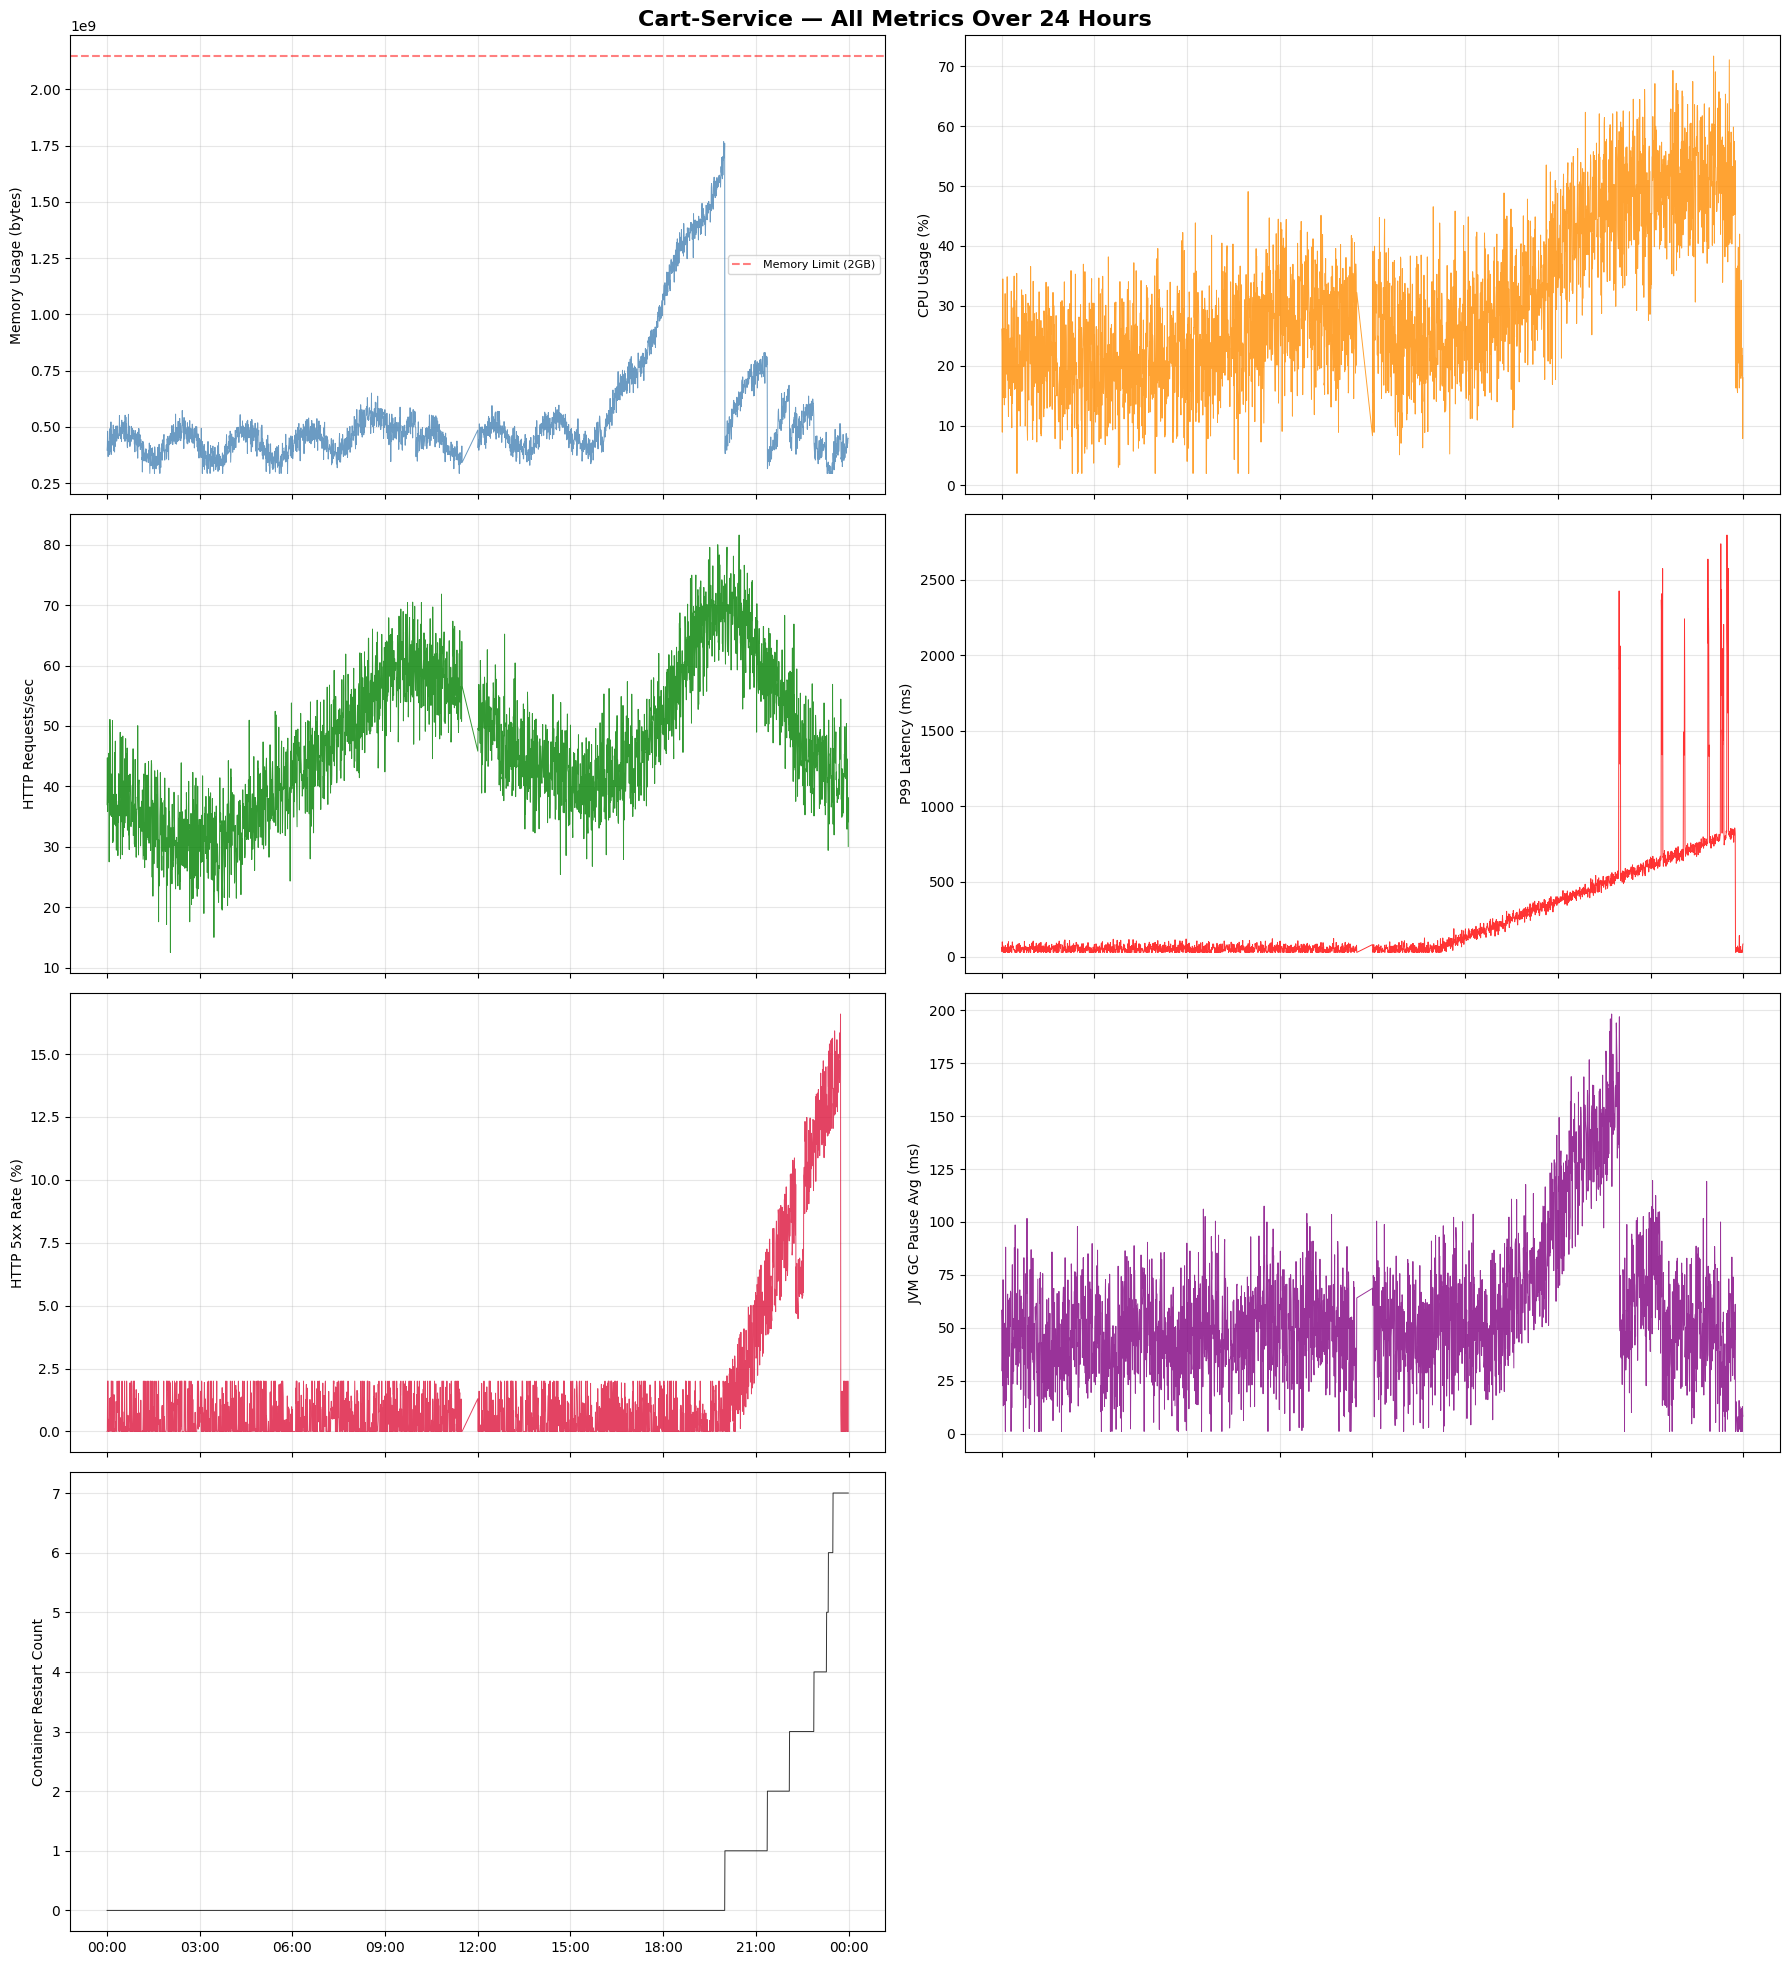

In [2]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
fig.suptitle('Cart-Service — All Metrics Over 24 Hours', fontsize=16, fontweight='bold')

metrics = [
    ('memory_usage_bytes', 'Memory Usage (bytes)', 'steelblue'),
    ('cpu_usage_percent', 'CPU Usage (%)', 'darkorange'),
    ('http_requests_per_sec', 'HTTP Requests/sec', 'green'),
    ('http_p99_latency_ms', 'P99 Latency (ms)', 'red'),
    ('http_5xx_rate', 'HTTP 5xx Rate (%)', 'crimson'),
    ('jvm_gc_pause_ms_avg', 'JVM GC Pause Avg (ms)', 'purple'),
    ('container_restart_count', 'Container Restart Count', 'black'),
]

for idx, (col, label, color) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.plot(cart['timestamp'], cart[col], linewidth=0.7, color=color, alpha=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Add memory limit line
axes[0, 0].axhline(y=2147483648, color='red', linestyle='--', alpha=0.5, label='Memory Limit (2GB)')
axes[0, 0].legend(fontsize=8)

# Hide unused subplot
axes[3, 1].set_visible(False)

plt.tight_layout()
plt.show()


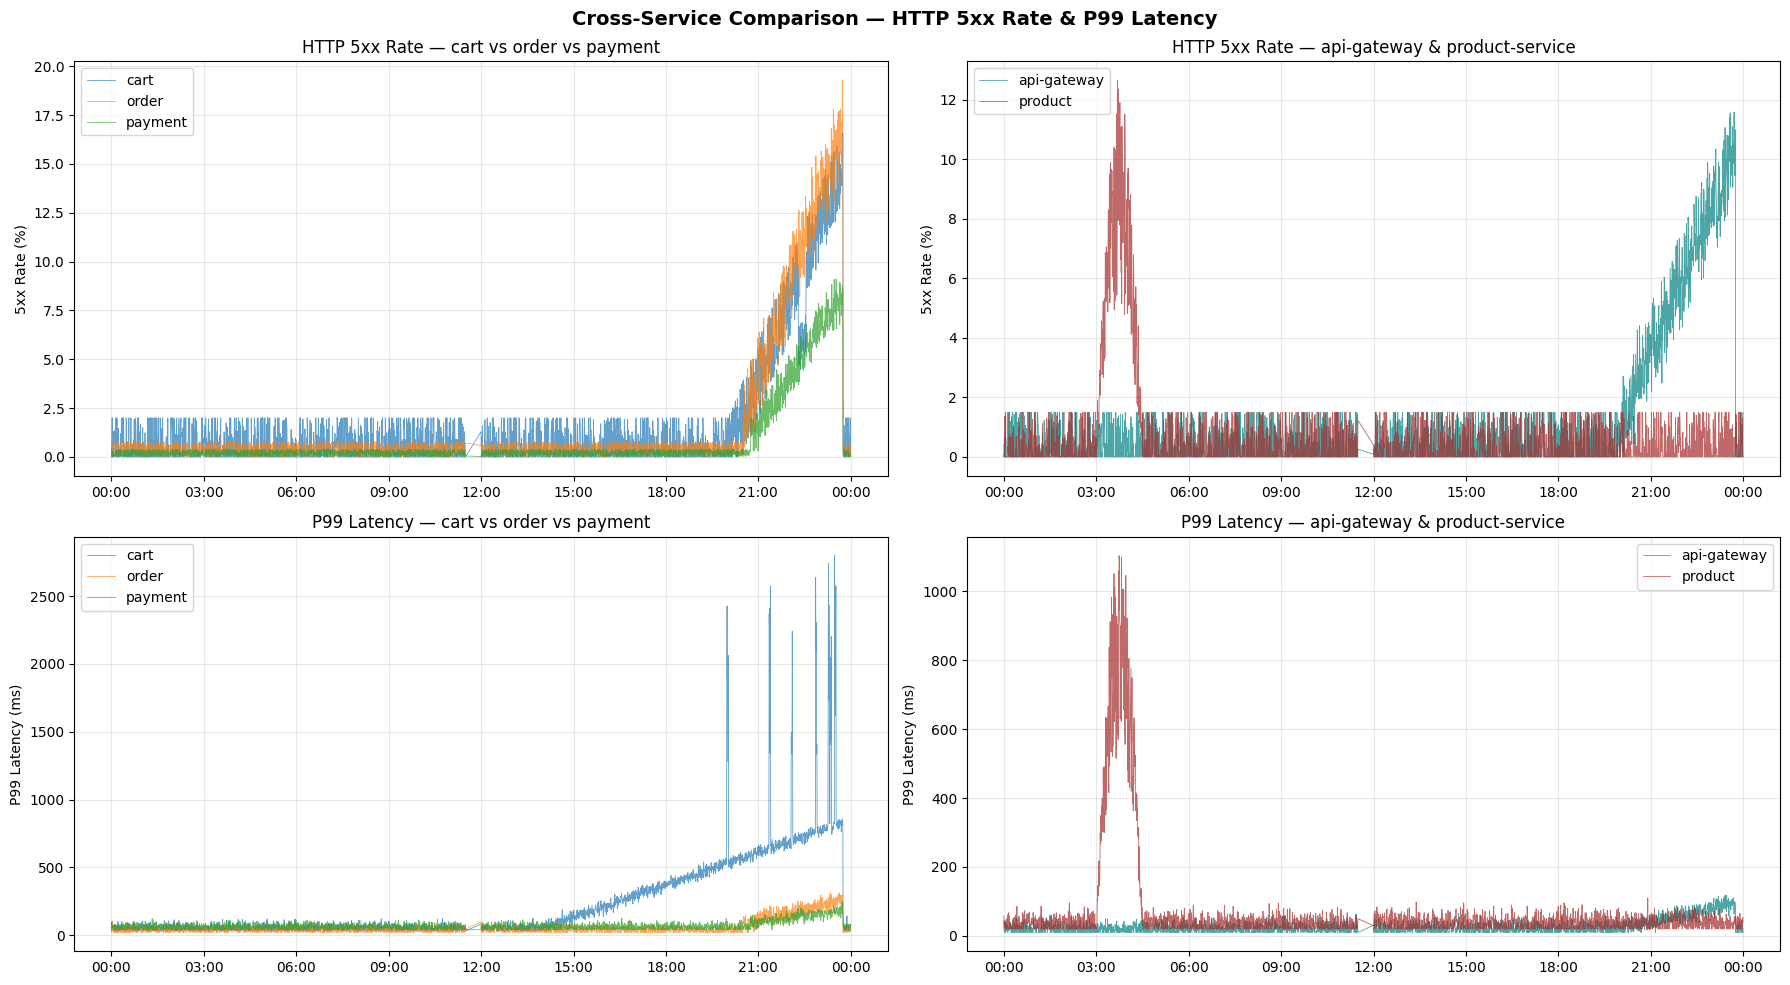

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Cross-Service Comparison — HTTP 5xx Rate & P99 Latency', fontsize=14, fontweight='bold')

# 5xx rates
ax = axes[0, 0]
ax.set_title('HTTP 5xx Rate — cart vs order vs payment')
ax.plot(cart['timestamp'], cart['http_5xx_rate'], label='cart', alpha=0.7, linewidth=0.6)
ax.plot(order['timestamp'], order['http_5xx_rate'], label='order', alpha=0.7, linewidth=0.6)
ax.plot(payment['timestamp'], payment['http_5xx_rate'], label='payment', alpha=0.7, linewidth=0.6)
ax.legend()
ax.set_ylabel('5xx Rate (%)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax = axes[0, 1]
ax.set_title('HTTP 5xx Rate — api-gateway & product-service')
ax.plot(gateway['timestamp'], gateway['http_5xx_rate'], label='api-gateway', alpha=0.7, linewidth=0.6, color='teal')
ax.plot(product['timestamp'], product['http_5xx_rate'], label='product', alpha=0.7, linewidth=0.6, color='brown')
ax.legend()
ax.set_ylabel('5xx Rate (%)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# P99 latency
ax = axes[1, 0]
ax.set_title('P99 Latency — cart vs order vs payment')
ax.plot(cart['timestamp'], cart['http_p99_latency_ms'], label='cart', alpha=0.7, linewidth=0.6)
ax.plot(order['timestamp'], order['http_p99_latency_ms'], label='order', alpha=0.7, linewidth=0.6)
ax.plot(payment['timestamp'], payment['http_p99_latency_ms'], label='payment', alpha=0.7, linewidth=0.6)
ax.legend()
ax.set_ylabel('P99 Latency (ms)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax = axes[1, 1]
ax.set_title('P99 Latency — api-gateway & product-service')
ax.plot(gateway['timestamp'], gateway['http_p99_latency_ms'], label='api-gateway', alpha=0.7, linewidth=0.6, color='teal')
ax.plot(product['timestamp'], product['http_p99_latency_ms'], label='product', alpha=0.7, linewidth=0.6, color='brown')
ax.legend()
ax.set_ylabel('P99 Latency (ms)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


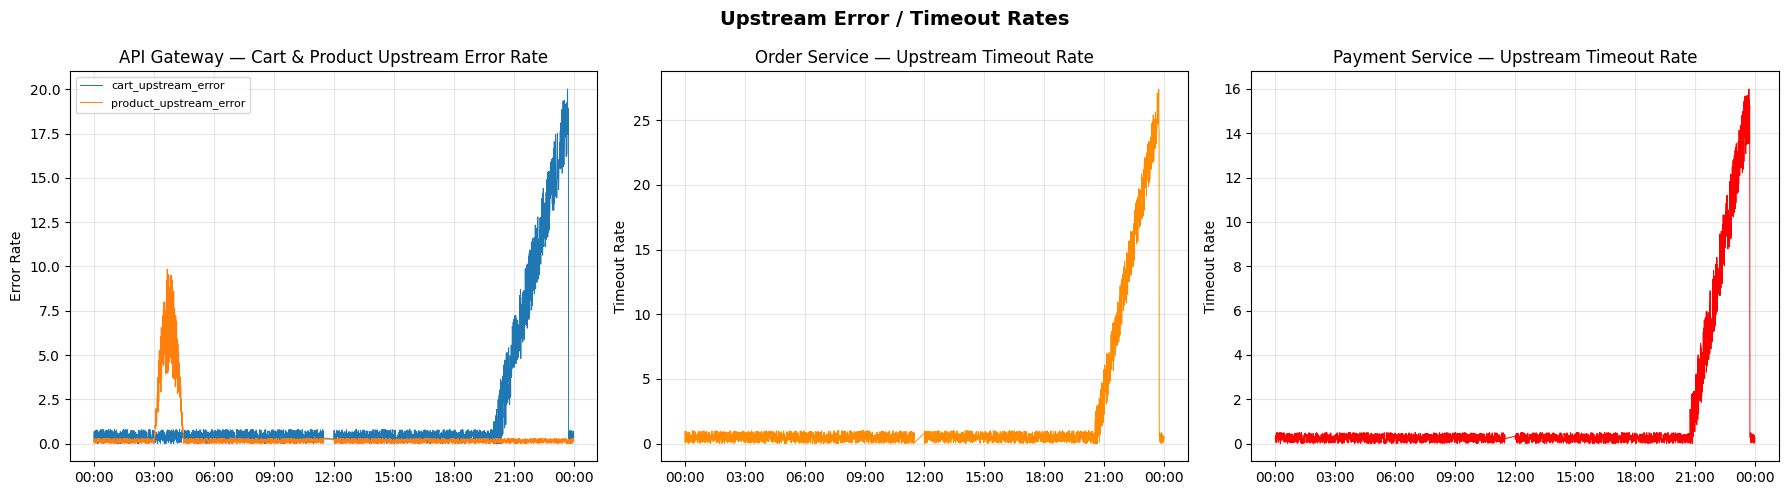

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Upstream Error / Timeout Rates', fontsize=14, fontweight='bold')

ax = axes[0]
ax.set_title('API Gateway — Cart & Product Upstream Error Rate')
ax.plot(gateway['timestamp'], gateway['cart_upstream_error_rate'], label='cart_upstream_error', linewidth=0.7)
ax.plot(gateway['timestamp'], gateway['product_upstream_error_rate'], label='product_upstream_error', linewidth=0.7)
ax.legend(fontsize=8)
ax.set_ylabel('Error Rate')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax = axes[1]
ax.set_title('Order Service — Upstream Timeout Rate')
ax.plot(order['timestamp'], order['upstream_timeout_rate'], linewidth=0.7, color='darkorange')
ax.set_ylabel('Timeout Rate')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax = axes[2]
ax.set_title('Payment Service — Upstream Timeout Rate')
ax.plot(payment['timestamp'], payment['upstream_timeout_rate'], linewidth=0.7, color='red')
ax.set_ylabel('Timeout Rate')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


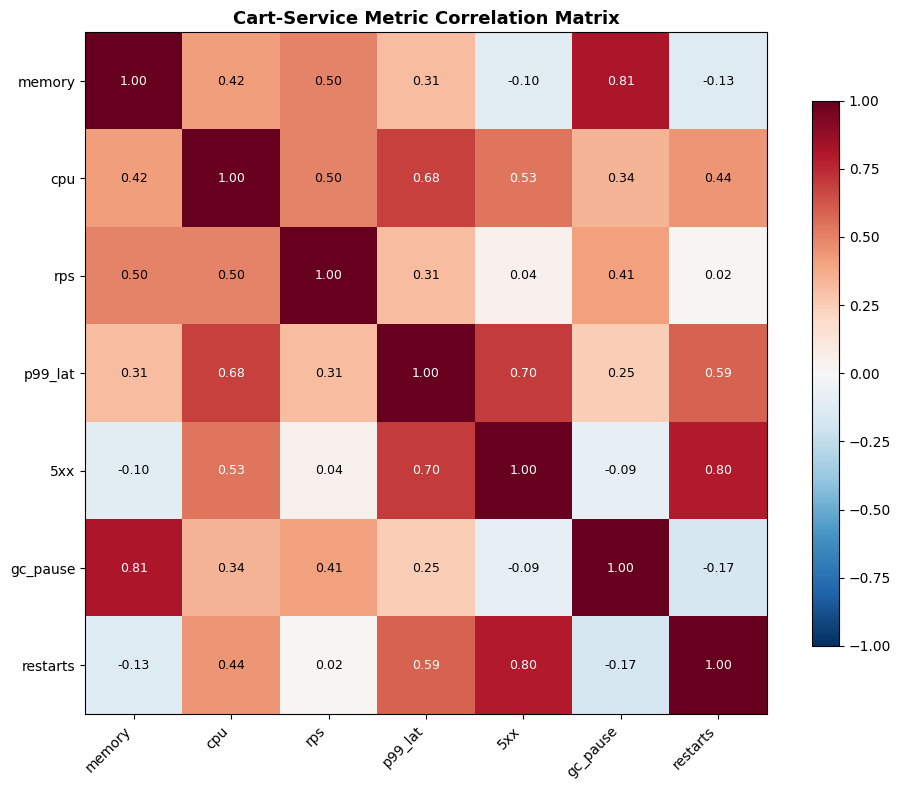

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['memory_usage_bytes', 'cpu_usage_percent', 'http_requests_per_sec',
             'http_p99_latency_ms', 'http_5xx_rate', 'jvm_gc_pause_ms_avg',
             'container_restart_count']
corr = cart[corr_cols].corr()

im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
short_labels = ['memory', 'cpu', 'rps', 'p99_lat', '5xx', 'gc_pause', 'restarts']
ax.set_xticklabels(short_labels, rotation=45, ha='right')
ax.set_yticklabels(short_labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Cart-Service Metric Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


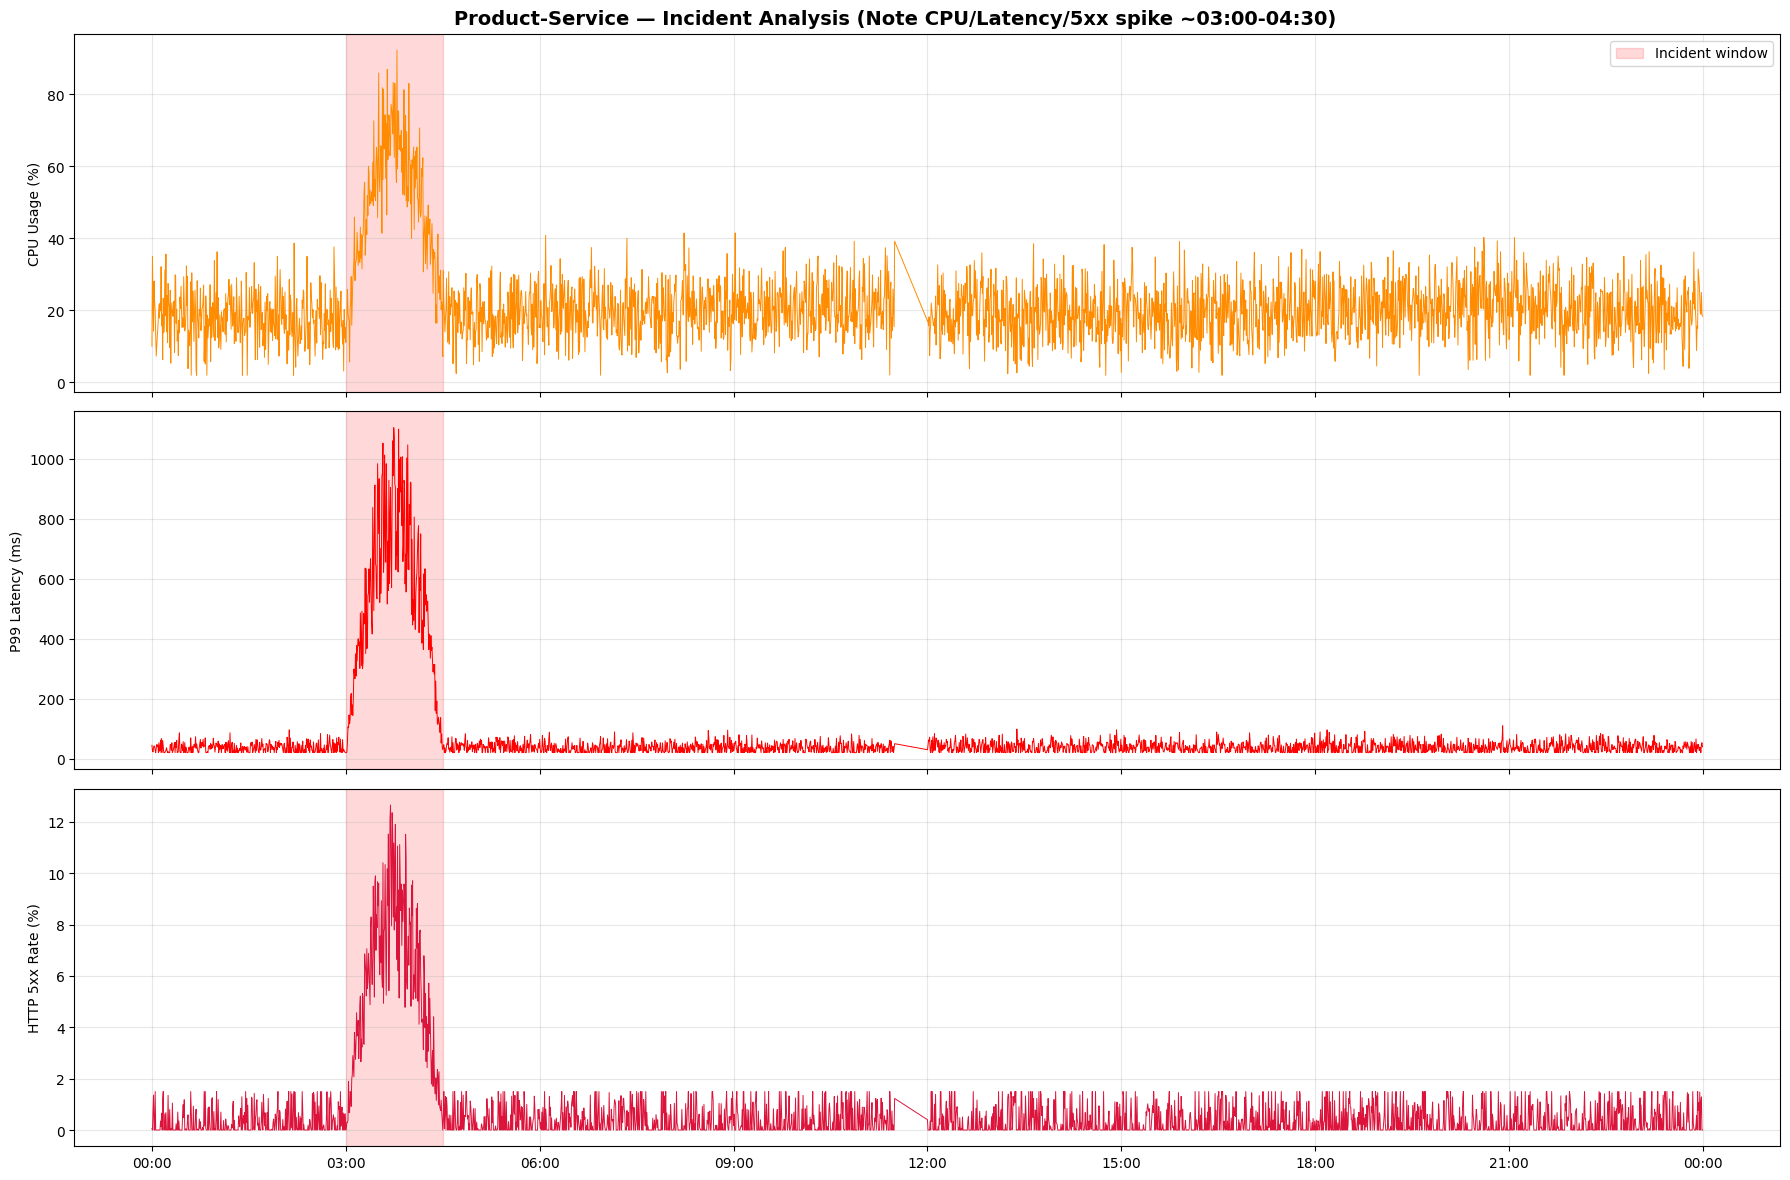

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('Product-Service — Incident Analysis (Note CPU/Latency/5xx spike ~03:00-04:30)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(product['timestamp'], product['cpu_usage_percent'], linewidth=0.7, color='darkorange')
ax.set_ylabel('CPU Usage (%)')
ax.axvspan(pd.Timestamp('2026-06-01 03:00'), pd.Timestamp('2026-06-01 04:30'), alpha=0.15, color='red', label='Incident window')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(product['timestamp'], product['http_p99_latency_ms'], linewidth=0.7, color='red')
ax.set_ylabel('P99 Latency (ms)')
ax.axvspan(pd.Timestamp('2026-06-01 03:00'), pd.Timestamp('2026-06-01 04:30'), alpha=0.15, color='red')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(product['timestamp'], product['http_5xx_rate'], linewidth=0.7, color='crimson')
ax.set_ylabel('HTTP 5xx Rate (%)')
ax.axvspan(pd.Timestamp('2026-06-01 03:00'), pd.Timestamp('2026-06-01 04:30'), alpha=0.15, color='red')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()
